# DS605: Fundamentals of Machine Learning

## Lab Assignment 6 — Feature Extraction and Machine Learning with Image and Text Data

### Objective

The objective of this lab is to convert raw image and text data into numerical feature representations and use traditional machine-learning models for classification.

This lab consists of three parts:

1. **Part A — Image Feature Extraction and Classification**
   - Preprocess asphalt crack images.
   - Extract intensity-based and edge-based features.
   - Train traditional machine-learning classifiers.
   - Evaluate classification performance.

2. **Part B — Text Vectorization and Spam Classification**
   - Preprocess email text.
   - Represent text using CountVectorizer and TF-IDF Vectorizer.
   - Train traditional machine-learning classifiers.
   - Compare the two text representations.

3. **Part C — Representation Improvement**
   - Modify at least one feature representation or modelling choice.
   - Compare the original and improved approaches.
   - Discuss the trade-off between feature dimensionality, computation time, and classification performance.

### Overall Workflow

Raw Data → Preprocessing → Feature Extraction / Vectorization → Train-Test Split → ML Model → Evaluation → Representation Improvement

# Part A — Image Feature Extraction and Classification

In this part, the Asphalt Crack Dataset will be used to classify images into crack and non-crack categories.

The images will first be inspected and preprocessed. Numerical features will then be extracted from the images using NumPy and OpenCV. These features will be used as input to traditional machine-learning classifiers.

The image-processing workflow is:

Image → Inspection → Resizing → Grayscale Conversion → Feature Extraction → Classification → Evaluation

## 1. Import Required Libraries

The following libraries will be used for image processing, numerical computation, data handling, visualization, and traditional machine learning.

In [2]:
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## 2. Inspect the Image Dataset Directory

Before processing the images, the dataset directory structure is inspected to identify the image classes and file organization.

In [3]:
# Path to the image dataset
image_dataset_path = "data/448"

# Paths to the two classes
crack_path = os.path.join(image_dataset_path, "Cracks")
noncrack_path = os.path.join(image_dataset_path, "NonCracks")

print("Dataset path:", image_dataset_path)
print("Cracks path:", crack_path)
print("NonCracks path:", noncrack_path)

print("\nCracks folder exists:", os.path.exists(crack_path))
print("NonCracks folder exists:", os.path.exists(noncrack_path))

Dataset path: data/448
Cracks path: data/448\Cracks
NonCracks path: data/448\NonCracks

Cracks folder exists: True
NonCracks folder exists: True


## 3. Inspect the Image Dataset

Before preprocessing the images, we inspect the dataset to understand:

- The number of images in each class
- The image file types
- The dimensions of the images
- The number of color channels

OpenCV is used to read the images. The `cv2.imread()` function loads a color image in BGR format by default.

In [4]:
# Get image filenames from both class folders
crack_files = [
    f for f in os.listdir(crack_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
]

noncrack_files = [
    f for f in os.listdir(noncrack_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
]

print("Number of crack images:", len(crack_files))
print("Number of non-crack images:", len(noncrack_files))
print("Total images:", len(crack_files) + len(noncrack_files))

print("\nSample crack filenames:")
print(crack_files[:5])

print("\nSample non-crack filenames:")
print(noncrack_files[:5])

Number of crack images: 200
Number of non-crack images: 200
Total images: 400

Sample crack filenames:
['IMG_20180513_164959951_HDR resized_448.jpg', 'IMG_20180513_165129852_HDR resized_448.jpg', 'IMG_20180513_165150613_HDR resized_448.jpg', 'IMG_20180513_165345878_HDR resized_448.jpg', 'IMG_20180513_165349788_HDR resized_448.jpg']

Sample non-crack filenames:
['IMG_20180705_130729936 resized_448.jpg', 'IMG_20180705_130731751 resized_448.jpg', 'IMG_20180705_130732496 resized_448.jpg', 'IMG_20180705_130732993 resized_448.jpg', 'IMG_20180705_130733329 resized_448.jpg']


## 4. Inspect Image Dimensions and Channels

A sample of images from both classes is loaded using OpenCV.

The dimensions and number of channels are inspected before preprocessing. This helps determine whether the images have a consistent size and color representation.

For a color image loaded by OpenCV, the shape is represented as:

(height, width, channels)

In [5]:
# Select one sample image from each class
sample_crack_path = os.path.join(crack_path, crack_files[0])
sample_noncrack_path = os.path.join(noncrack_path, noncrack_files[0])

# Read images using OpenCV
sample_crack = cv2.imread(sample_crack_path)
sample_noncrack = cv2.imread(sample_noncrack_path)

# Display image information
print("Crack image:")
print("  Filename:", crack_files[0])
print("  Shape:", sample_crack.shape)
print("  Height:", sample_crack.shape[0])
print("  Width:", sample_crack.shape[1])
print("  Channels:", sample_crack.shape[2])

print("\nNon-crack image:")
print("  Filename:", noncrack_files[0])
print("  Shape:", sample_noncrack.shape)
print("  Height:", sample_noncrack.shape[0])
print("  Width:", sample_noncrack.shape[1])
print("  Channels:", sample_noncrack.shape[2])

Crack image:
  Filename: IMG_20180513_164959951_HDR resized_448.jpg
  Shape: (448, 448, 3)
  Height: 448
  Width: 448
  Channels: 3

Non-crack image:
  Filename: IMG_20180705_130729936 resized_448.jpg
  Shape: (448, 448, 3)
  Height: 448
  Width: 448
  Channels: 3


## 5. Visualize Sample Images

A sample image from each class is displayed to visually inspect the difference between crack and non-crack images.

OpenCV loads color images in BGR format, whereas Matplotlib expects RGB format. Therefore, the images are converted from BGR to RGB before visualization.

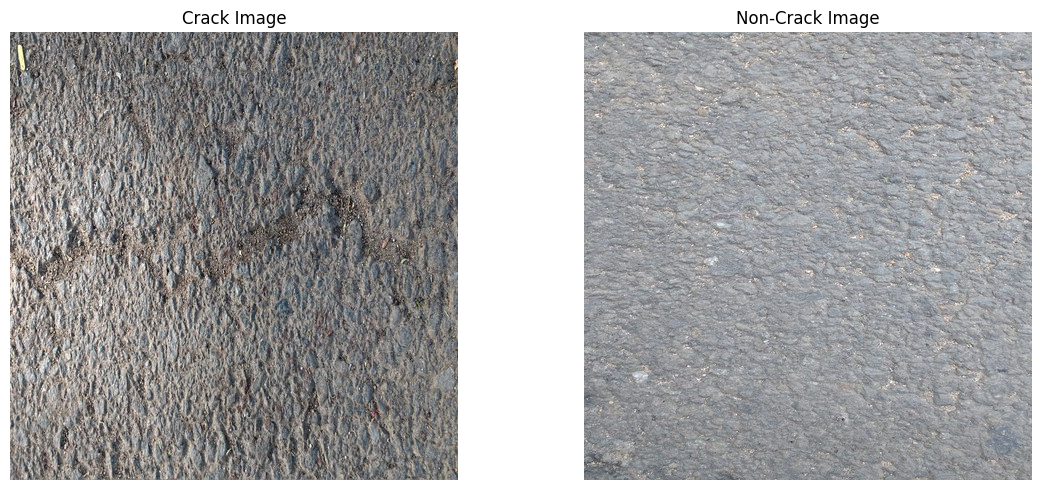

In [6]:
# Convert BGR images to RGB for Matplotlib
sample_crack_rgb = cv2.cvtColor(sample_crack, cv2.COLOR_BGR2RGB)
sample_noncrack_rgb = cv2.cvtColor(sample_noncrack, cv2.COLOR_BGR2RGB)

# Display sample images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_crack_rgb)
plt.title("Crack Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_noncrack_rgb)
plt.title("Non-Crack Image")
plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Image Preprocessing — Resizing and Grayscale Conversion

The images are resized to a common resolution of 448 × 448 pixels. Although the current dataset images are already 448 × 448, explicitly applying the resizing operation ensures that all images have a consistent representation.

The resized color images are then converted from BGR to grayscale using OpenCV.

A grayscale image contains a single intensity value for each pixel, ranging from 0 (black) to 255 (white). This representation is used for extracting intensity-based and edge-based features.

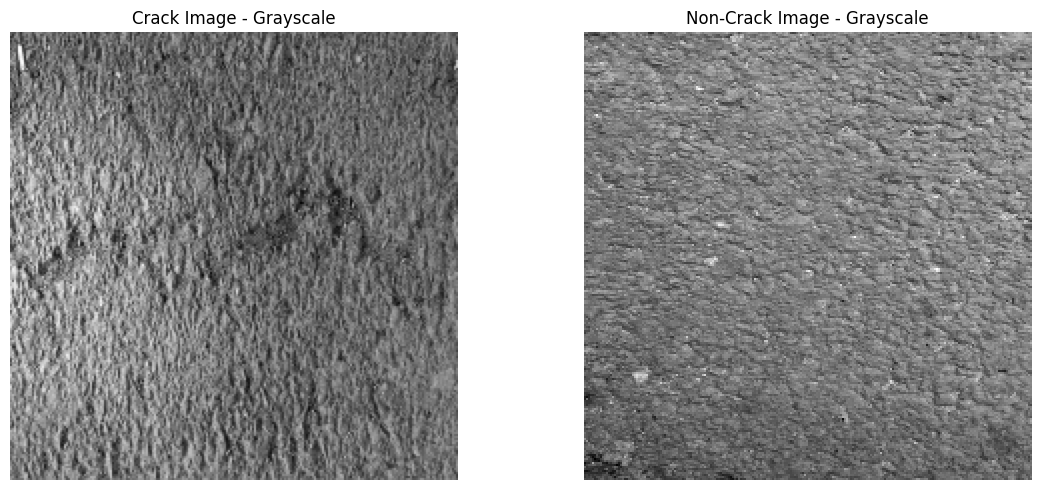

Crack grayscale shape: (224, 224)
Non-crack grayscale shape: (224, 224)


In [7]:
# Common image dimensions
image_size = (224, 224)  # Width x Height

# Resize the sample images
sample_crack_resized = cv2.resize(sample_crack, image_size)
sample_noncrack_resized = cv2.resize(sample_noncrack, image_size)

# Convert resized images to grayscale
sample_crack_gray = cv2.cvtColor(sample_crack_resized, cv2.COLOR_BGR2GRAY)
sample_noncrack_gray = cv2.cvtColor(sample_noncrack_resized, cv2.COLOR_BGR2GRAY)

# Display the grayscale images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_crack_gray, cmap="gray")
plt.title("Crack Image - Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_noncrack_gray, cmap="gray")
plt.title("Non-Crack Image - Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

# Display shapes
print("Crack grayscale shape:", sample_crack_gray.shape)
print("Non-crack grayscale shape:", sample_noncrack_gray.shape)

## 7. Intensity-Based Feature Extraction

Grayscale images contain pixel intensity values ranging from 0 to 255. These values can be summarized into numerical features that describe the overall appearance of an image.

The following features are extracted:

- **Mean brightness:** Average pixel intensity.
- **Contrast:** Standard deviation of pixel intensities, representing the variation in brightness.
- **Dark-pixel ratio:** Proportion of pixels below a specified dark-intensity threshold.
- **Bright-pixel ratio:** Proportion of pixels above a specified bright-intensity threshold.
- **Minimum intensity:** Lowest pixel intensity in the image.
- **Maximum intensity:** Highest pixel intensity in the image.
- **Median intensity:** Middle pixel intensity when all pixel values are ordered.

These features provide a compact numerical representation of the grayscale image.

In [8]:
def extract_intensity_features(gray_image):
    """
    Extract intensity-based features from a grayscale image.
    """

    # Convert pixel values to float for numerical calculations
    pixels = gray_image.astype(np.float32)

    # Intensity thresholds
    dark_threshold = 50
    bright_threshold = 200

    # Calculate intensity features
    mean_brightness = np.mean(pixels)
    contrast = np.std(pixels)

    dark_pixel_ratio = np.mean(pixels < dark_threshold)
    bright_pixel_ratio = np.mean(pixels > bright_threshold)

    min_intensity = np.min(pixels)
    max_intensity = np.max(pixels)
    median_intensity = np.median(pixels)

    return {
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "median_intensity": median_intensity
    }

In [9]:
# Extract features from the sample images
crack_intensity_features = extract_intensity_features(sample_crack_gray)
noncrack_intensity_features = extract_intensity_features(sample_noncrack_gray)

print("Crack image features:")
for feature, value in crack_intensity_features.items():
    print(f"{feature}: {value:.4f}")

print("\nNon-crack image features:")
for feature, value in noncrack_intensity_features.items():
    print(f"{feature}: {value:.4f}")

Crack image features:
mean_brightness: 122.2246
contrast: 31.5135
dark_pixel_ratio: 0.0038
bright_pixel_ratio: 0.0109
min_intensity: 23.0000
max_intensity: 247.0000
median_intensity: 121.0000

Non-crack image features:
mean_brightness: 157.3580
contrast: 15.4728
dark_pixel_ratio: 0.0000
bright_pixel_ratio: 0.0039
min_intensity: 82.0000
max_intensity: 240.0000
median_intensity: 157.0000


## 8. Canny Edge Detection and Edge-Based Features

Cracks in asphalt can produce distinct intensity transitions and edge structures. To capture this information, Canny edge detection is applied to the grayscale images using OpenCV.

The resulting binary edge image contains:

- `255` for detected edge pixels
- `0` for non-edge pixels

Two numerical features are extracted:

- **Edge count:** Total number of detected edge pixels.
- **Edge density:** Proportion of image pixels identified as edges.

Edge density is calculated as:

\[
\text{Edge Density}
=
\frac{\text{Number of Edge Pixels}}
{\text{Total Number of Pixels}}
\]

Canny edge detection is performed directly on the grayscale image.

In [10]:
def extract_edge_features(gray_image, lower_threshold=50, upper_threshold=150):
    """
    Apply Canny edge detection and extract edge-based features.
    """

    # Apply Canny edge detection
    edges = cv2.Canny(
        gray_image,
        threshold1=lower_threshold,
        threshold2=upper_threshold
    )

    # Count detected edge pixels
    edge_count = np.count_nonzero(edges)

    # Calculate total number of pixels
    total_pixels = edges.size

    # Calculate edge density
    edge_density = edge_count / total_pixels

    return {
        "edge_count": edge_count,
        "edge_density": edge_density
    }, edges

In [11]:
# Extract Canny edge features
crack_edge_features, crack_edges = extract_edge_features(sample_crack_gray)
noncrack_edge_features, noncrack_edges = extract_edge_features(sample_noncrack_gray)

print("Crack image edge features:")
for feature, value in crack_edge_features.items():
    print(f"{feature}: {value:.4f}")

print("\nNon-crack image edge features:")
for feature, value in noncrack_edge_features.items():
    print(f"{feature}: {value:.4f}")

Crack image edge features:
edge_count: 18520.0000
edge_density: 0.3691

Non-crack image edge features:
edge_count: 15721.0000
edge_density: 0.3133


## 9. Visualize Canny Edge Detection

The Canny edge maps of a crack and a non-crack image are visualized to understand the edge information extracted from the asphalt images.

The edge maps are binary representations where detected edges are highlighted.

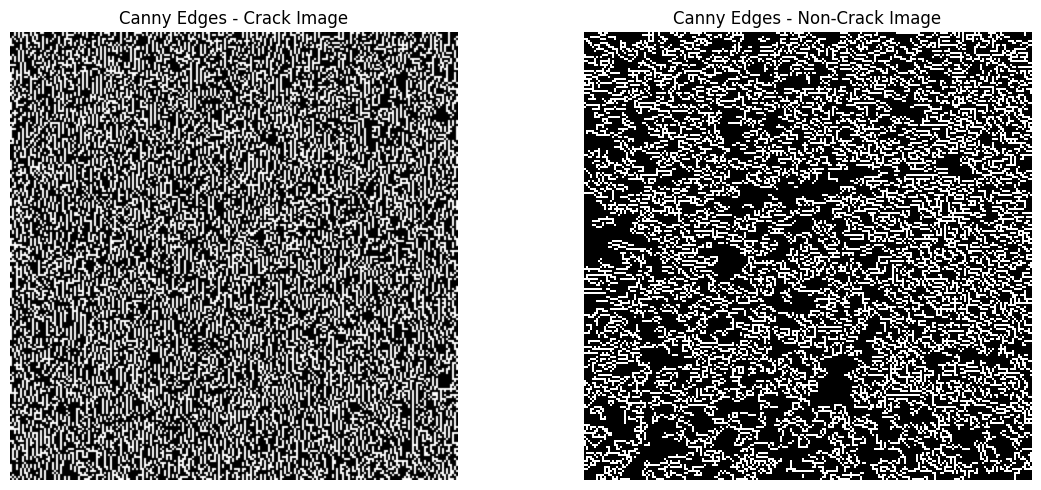

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(crack_edges, cmap="gray")
plt.title("Canny Edges - Crack Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noncrack_edges, cmap="gray")
plt.title("Canny Edges - Non-Crack Image")
plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Extract Features from the Complete Image Dataset

The previously defined intensity-based and edge-based feature extraction functions are applied to all images in the dataset.

For each image, the following steps are performed:

1. Read the image using OpenCV.
2. Resize it to 224 × 224 pixels.
3. Convert it to grayscale.
4. Extract intensity-based features.
5. Apply Canny edge detection.
6. Extract edge-based features.
7. Store the features together with the image filename and class label.

The resulting DataFrame contains one row per image.

In [13]:
# Function to process a single image and extract all required features
def extract_image_features(image_path, label):
    # Read image using OpenCV
    image = cv2.imread(image_path)

    if image is None:
        return None

    # Resize image
    resized_image = cv2.resize(image, image_size)

    # Convert to grayscale
    gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

    # Extract intensity features
    intensity_features = extract_intensity_features(gray_image)

    # Extract Canny edge features
    edge_features, _ = extract_edge_features(
        gray_image,
        lower_threshold=50,
        upper_threshold=150
    )

    # Combine all features
    feature_row = {
        "filename": os.path.basename(image_path),
        "label": label
    }

    feature_row.update(intensity_features)
    feature_row.update(edge_features)

    return feature_row

In [14]:
# Store extracted feature rows
image_feature_rows = []

# Process crack images
for filename in crack_files:
    image_path = os.path.join(crack_path, filename)

    features = extract_image_features(
        image_path=image_path,
        label="Crack"
    )

    if features is not None:
        image_feature_rows.append(features)

# Process non-crack images
for filename in noncrack_files:
    image_path = os.path.join(noncrack_path, filename)

    features = extract_image_features(
        image_path=image_path,
        label="NonCrack"
    )

    if features is not None:
        image_feature_rows.append(features)

# Create the final feature DataFrame
image_features_df = pd.DataFrame(image_feature_rows)

print("Feature extraction completed.")
print("Number of rows:", len(image_features_df))
print("Number of columns:", len(image_features_df.columns))

image_features_df.head()

Feature extraction completed.
Number of rows: 400
Number of columns: 11


,filename,label,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,min_intensity,max_intensity,median_intensity,edge_count,edge_density
0,IMG_20180513_164959951_HDR resized_448.jpg,Crack,122.224609,31.513483,0.003846,0.010922,23.0,247.0,121.0,18520,0.369101
1,IMG_20180513_165129852_HDR resized_448.jpg,Crack,131.948685,24.096113,0.002790,0.003787,8.0,251.0,133.0,18094,0.360611
2,IMG_20180513_165150613_HDR resized_448.jpg,Crack,121.297310,29.884272,0.013333,0.008171,2.0,241.0,121.0,17454,0.347856
3,IMG_20180513_165345878_HDR resized_448.jpg,Crack,130.245590,25.649017,0.001893,0.004006,20.0,253.0,131.0,18767,0.374023
4,IMG_20180513_165349788_HDR resized_448.jpg,Crack,131.208878,26.237597,0.002372,0.006258,11.0,254.0,132.0,18349,0.365693


## 11. Validate the Extracted Feature Dataset

Before applying machine-learning models, the extracted feature dataset is checked for:

- Dataset dimensions
- Missing values
- Class distribution
- Data types

This ensures that the feature extraction process produced a complete and valid dataset for classification.

In [15]:
# Display all feature columns
print("Feature columns:")
print(image_features_df.columns.tolist())

# Check dataset dimensions
print("\nDataset shape:", image_features_df.shape)

# Check missing values
print("\nMissing values:")
print(image_features_df.isnull().sum())

# Check class distribution
print("\nClass distribution:")
print(image_features_df["label"].value_counts())

# Check data types
print("\nData types:")
print(image_features_df.dtypes)

Feature columns:
['filename', 'label', 'mean_brightness', 'contrast', 'dark_pixel_ratio', 'bright_pixel_ratio', 'min_intensity', 'max_intensity', 'median_intensity', 'edge_count', 'edge_density']

Dataset shape: (400, 11)

Missing values:
filename              0
label                 0
mean_brightness       0
contrast              0
dark_pixel_ratio      0
bright_pixel_ratio    0
min_intensity         0
max_intensity         0
median_intensity      0
edge_count            0
edge_density          0
dtype: int64

Class distribution:
label
Crack       200
NonCrack    200
Name: count, dtype: int64

Data types:
filename               object
label                  object
mean_brightness       float32
contrast              float32
dark_pixel_ratio      float64
bright_pixel_ratio    float64
min_intensity         float32
max_intensity         float32
median_intensity      float32
edge_count              int64
edge_density          float64
dtype: object


## 12. Exploratory Analysis of Extracted Image Features

The extracted numerical features are summarized separately for the Crack and NonCrack classes.

Comparing the class-wise feature means provides an initial understanding of whether the handcrafted intensity and edge features contain differences between the two classes.

These observations are descriptive and do not replace the evaluation of the machine-learning classifiers.

In [16]:
# Select numerical image features
image_feature_columns = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "edge_count",
    "edge_density"
]

# Calculate class-wise mean values
class_feature_means = (
    image_features_df
    .groupby("label")[image_feature_columns]
    .mean()
    .T
)

class_feature_means

label,Crack,NonCrack
mean_brightness,144.372375,157.632278
contrast,30.006721,23.024330
dark_pixel_ratio,0.007858,0.000298
bright_pixel_ratio,0.068391,0.040841
min_intensity,28.620001,67.360001
max_intensity,251.300003,250.100006
median_intensity,144.649994,157.335007
edge_count,18376.615000,16974.375000
edge_density,0.366243,0.338297


## 13. Visual Comparison of Selected Image Features

Boxplots are used to compare selected handcrafted features between the Crack and NonCrack classes.

The selected features represent different aspects of the images:

- Mean brightness — overall image intensity
- Contrast — variation in intensity
- Dark-pixel ratio — proportion of darker pixels
- Edge density — proportion of pixels detected as edges

These plots provide a visual exploratory analysis before machine-learning classification.

<Figure size 700x500 with 0 Axes>

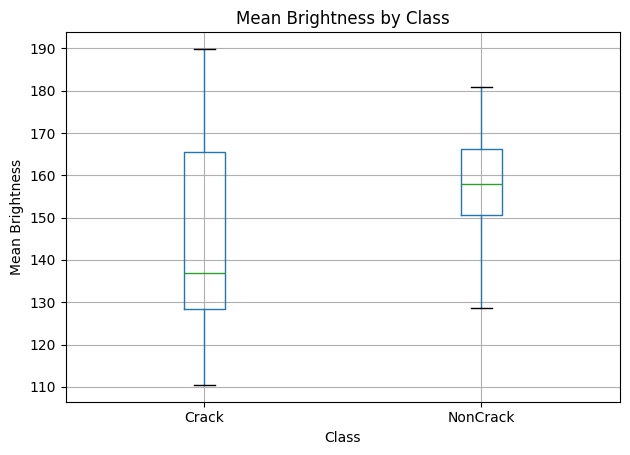

<Figure size 700x500 with 0 Axes>

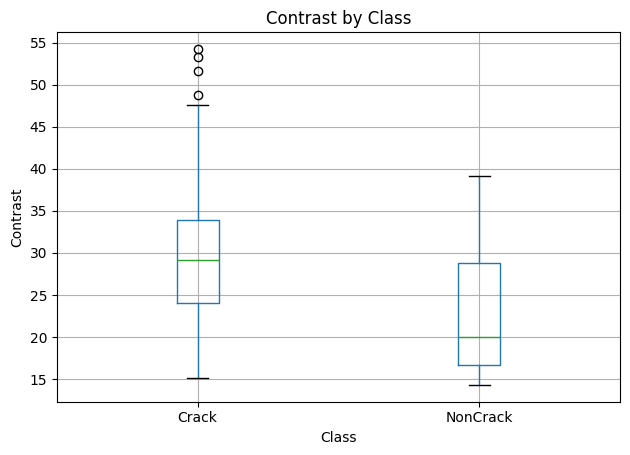

<Figure size 700x500 with 0 Axes>

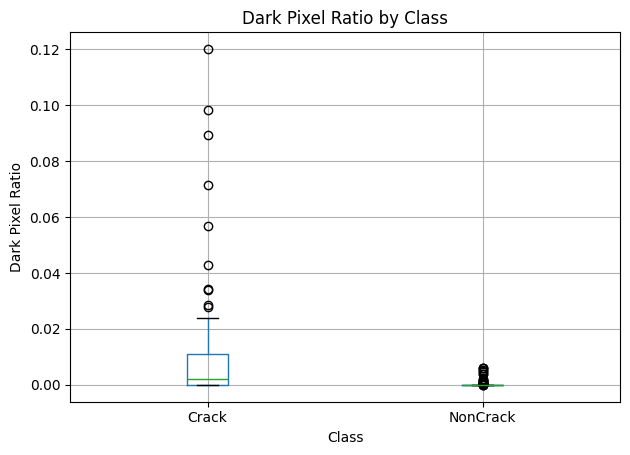

<Figure size 700x500 with 0 Axes>

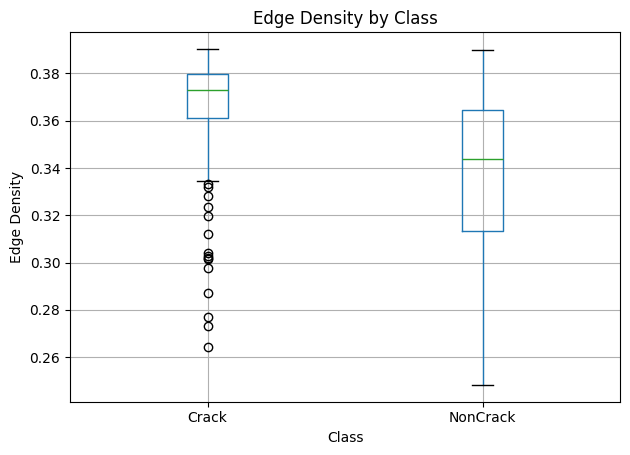

In [17]:
# Features selected for visualization
selected_visual_features = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "edge_density"
]

# Create one plot for each feature
for feature in selected_visual_features:
    plt.figure(figsize=(7, 5))
    
    image_features_df.boxplot(
        column=feature,
        by="label"
    )
    
    plt.title(f"{feature.replace('_', ' ').title()} by Class")
    plt.suptitle("")
    plt.xlabel("Class")
    plt.ylabel(feature.replace("_", " ").title())
    plt.tight_layout()
    plt.show()

## 14. Prepare Data for Machine Learning

The extracted numerical features are separated into:

- `X`: input features used by the machine-learning models.
- `y`: target variable representing the image class.

The filename is excluded because it is an identifier rather than a predictive feature.

The target labels are encoded as:

- `0` → NonCrack
- `1` → Crack

The dataset is then divided into training and testing sets using a stratified split so that both sets maintain the original class distribution.

In [18]:
# Define input features and target
X_image = image_features_df[image_feature_columns].copy()

# Encode labels: NonCrack = 0, Crack = 1
y_image = image_features_df["label"].map({
    "NonCrack": 0,
    "Crack": 1
})

print("Feature matrix shape:", X_image.shape)
print("Target shape:", y_image.shape)

print("\nClass counts:")
print(y_image.value_counts())

Feature matrix shape: (400, 9)
Target shape: (400,)

Class counts:
label
1    200
0    200
Name: count, dtype: int64


## 15. Train-Test Split

The feature dataset is divided into training and testing subsets using an 80:20 split.

- 80% of the images are used for training.
- 20% of the images are reserved for final evaluation.

A stratified split is used so that the Crack and NonCrack classes remain proportionally represented in both subsets.

The test set is kept separate from model training and is used only for evaluating the final classifiers.

In [19]:
# Split the image dataset into training and testing sets
X_image_train, X_image_test, y_image_train, y_image_test = train_test_split(
    X_image,
    y_image,
    test_size=0.20,
    random_state=42,
    stratify=y_image
)

print("Training feature shape:", X_image_train.shape)
print("Testing feature shape:", X_image_test.shape)

print("\nTraining class distribution:")
print(y_image_train.value_counts())

print("\nTesting class distribution:")
print(y_image_test.value_counts())

Training feature shape: (320, 9)
Testing feature shape: (80, 9)

Training class distribution:
label
1    160
0    160
Name: count, dtype: int64

Testing class distribution:
label
0    40
1    40
Name: count, dtype: int64


## 16. Logistic Regression Classifier

Logistic Regression is used as the first traditional machine-learning classifier for the extracted image features.

Since the features have different numerical scales, standardization is applied before training. The classifier is evaluated using the test set.

Both training time and prediction time are recorded as required by the assignment.

In [20]:
# Create Logistic Regression pipeline
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

# Measure training time
logistic_start_time = time.perf_counter()

logistic_model.fit(X_image_train, y_image_train)

logistic_training_time = time.perf_counter() - logistic_start_time

# Measure prediction time
logistic_prediction_start_time = time.perf_counter()

y_image_pred_logistic = logistic_model.predict(X_image_test)

logistic_prediction_time = time.perf_counter() - logistic_prediction_start_time

print(f"Training time: {logistic_training_time:.6f} seconds")
print(f"Prediction time: {logistic_prediction_time:.6f} seconds")

Training time: 0.039783 seconds
Prediction time: 0.002196 seconds


C:\Users\pujit\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


## 17. Evaluate Logistic Regression

The Logistic Regression classifier is evaluated on the unseen test set using the following metrics:

- **Accuracy:** Proportion of correctly classified images.
- **Precision:** Proportion of images predicted as a class that actually belong to that class.
- **Recall:** Proportion of actual images of a class that are correctly identified.
- **F1-score:** Harmonic mean of precision and recall.
- **Confusion Matrix:** Shows the number of correct and incorrect predictions for each class.

These metrics provide a more complete evaluation than accuracy alone.

In [21]:
# Calculate evaluation metrics
logistic_accuracy = accuracy_score(y_image_test, y_image_pred_logistic)
logistic_precision = precision_score(y_image_test, y_image_pred_logistic)
logistic_recall = recall_score(y_image_test, y_image_pred_logistic)
logistic_f1 = f1_score(y_image_test, y_image_pred_logistic)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1-score : {logistic_f1:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.9375
Precision: 0.9268
Recall   : 0.9500
F1-score : 0.9383


## 18. Confusion Matrix — Logistic Regression

A confusion matrix is used to examine the individual classification outcomes for the Crack and NonCrack classes.

The matrix contains:

- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

For this classification task:

- Class `0` = NonCrack
- Class `1` = Crack

Confusion Matrix:
[[37  3]
 [ 2 38]]


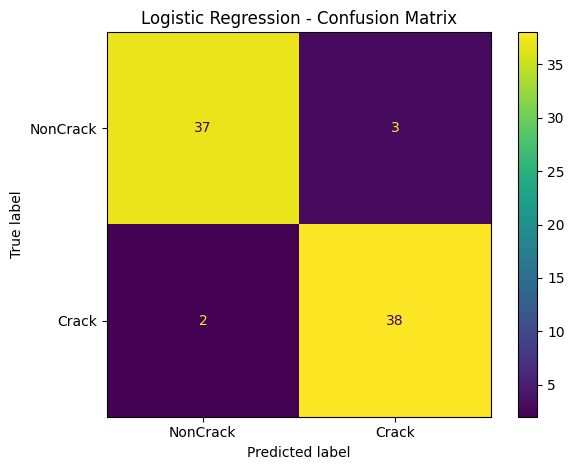

In [22]:
# Calculate confusion matrix
logistic_cm = confusion_matrix(
    y_image_test,
    y_image_pred_logistic
)

print("Confusion Matrix:")
print(logistic_cm)

# Visualize confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["NonCrack", "Crack"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

## 19. Random Forest Classifier

A Random Forest classifier is trained as a second traditional machine-learning approach.

Random Forest combines multiple decision trees and can model nonlinear relationships between the extracted image features and the target class.

Unlike Logistic Regression, feature standardization is not required for Random Forest.

Training time and prediction time are measured for comparison with Logistic Regression.

In [23]:
# Create Random Forest classifier
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Measure training time
rf_start_time = time.perf_counter()

random_forest_model.fit(X_image_train, y_image_train)

rf_training_time = time.perf_counter() - rf_start_time

# Measure prediction time
rf_prediction_start_time = time.perf_counter()

y_image_pred_rf = random_forest_model.predict(X_image_test)

rf_prediction_time = time.perf_counter() - rf_prediction_start_time

print(f"Training time: {rf_training_time:.6f} seconds")
print(f"Prediction time: {rf_prediction_time:.6f} seconds")

Training time: 0.246541 seconds
Prediction time: 0.010555 seconds


## 20. Evaluate Random Forest

The Random Forest classifier is evaluated on the same unseen test set used for Logistic Regression.

The following metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-score

Using the same test set allows a direct comparison between the two classifiers.

In [24]:
# Calculate Random Forest evaluation metrics
rf_accuracy = accuracy_score(y_image_test, y_image_pred_rf)
rf_precision = precision_score(y_image_test, y_image_pred_rf)
rf_recall = recall_score(y_image_test, y_image_pred_rf)
rf_f1 = f1_score(y_image_test, y_image_pred_rf)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")

Random Forest Results
-----------------------------------
Accuracy : 0.9500
Precision: 0.9500
Recall   : 0.9500
F1-score : 0.9500


## 21. Confusion Matrix — Random Forest

The confusion matrix is generated for the Random Forest classifier to examine the correct and incorrect predictions for the Crack and NonCrack classes.

The same test set used for Logistic Regression is used here to ensure that the two classifiers can be compared consistently.

Random Forest Confusion Matrix:
[[38  2]
 [ 2 38]]


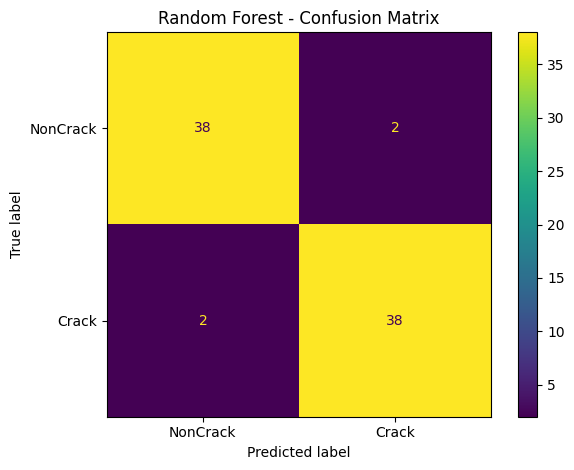

In [25]:
# Calculate confusion matrix
rf_cm = confusion_matrix(
    y_image_test,
    y_image_pred_rf
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

# Visualize confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["NonCrack", "Crack"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()

plt.show()

## 22. Comparison of Image Classification Models

The performance of Logistic Regression and Random Forest is compared using the required evaluation metrics and computational measurements.

The comparison includes:

- Accuracy
- Precision
- Recall
- F1-score
- Training time
- Prediction time

Both models were evaluated using the same 80-image test set.

In [26]:
# Create a comparison table for the image classifiers
image_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1-Score": [
        logistic_f1,
        rf_f1
    ],
    "Training Time (s)": [
        logistic_training_time,
        rf_training_time
    ],
    "Prediction Time (s)": [
        logistic_prediction_time,
        rf_prediction_time
    ]
})

image_model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9375,0.926829,0.95,0.938272,0.039783,0.002196
1,Random Forest,0.9500,0.950000,0.95,0.950000,0.246541,0.010555


## 23. Decision Tree Classifier

A Decision Tree classifier is trained using the extracted image features.

Unlike Logistic Regression and SVM, a Decision Tree does not require feature standardization because it makes decisions based on feature thresholds.

Training time and prediction time are recorded so that the model can be compared with the other classifiers.

In [27]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree classifier
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Measure training time
dt_start_time = time.perf_counter()

decision_tree_model.fit(X_image_train, y_image_train)

dt_training_time = time.perf_counter() - dt_start_time

# Measure prediction time
dt_prediction_start_time = time.perf_counter()

y_image_pred_dt = decision_tree_model.predict(X_image_test)

dt_prediction_time = time.perf_counter() - dt_prediction_start_time

print(f"Training time: {dt_training_time:.6f} seconds")
print(f"Prediction time: {dt_prediction_time:.6f} seconds")

Training time: 0.004473 seconds
Prediction time: 0.001706 seconds


## 24. Evaluate Decision Tree

The Decision Tree classifier is evaluated on the same test set used for the other image classifiers.

Accuracy, precision, recall, and F1-score are calculated to allow direct comparison with Logistic Regression and Random Forest.

In [28]:
# Calculate Decision Tree evaluation metrics
dt_accuracy = accuracy_score(y_image_test, y_image_pred_dt)
dt_precision = precision_score(y_image_test, y_image_pred_dt)
dt_recall = recall_score(y_image_test, y_image_pred_dt)
dt_f1 = f1_score(y_image_test, y_image_pred_dt)

print("Decision Tree Results")
print("-" * 35)
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-score : {dt_f1:.4f}")

Decision Tree Results
-----------------------------------
Accuracy : 0.9375
Precision: 0.9487
Recall   : 0.9250
F1-score : 0.9367


## 25. Confusion Matrix — Decision Tree

The confusion matrix is generated for the Decision Tree classifier to examine the correct and incorrect predictions for the Crack and NonCrack classes.

Decision Tree Confusion Matrix:
[[38  2]
 [ 3 37]]


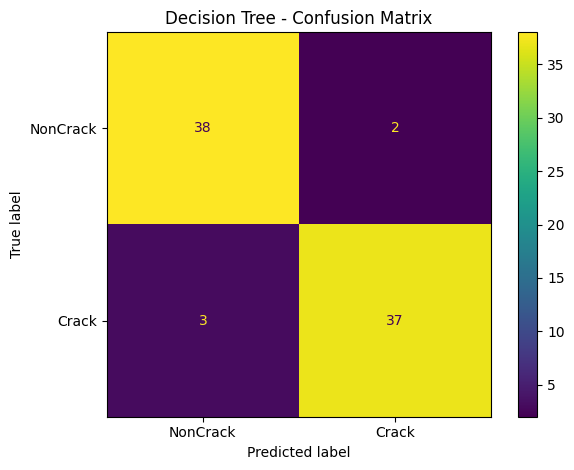

In [29]:
# Calculate confusion matrix
dt_cm = confusion_matrix(
    y_image_test,
    y_image_pred_dt
)

print("Decision Tree Confusion Matrix:")
print(dt_cm)

# Visualize confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["NonCrack", "Crack"]
).plot()

plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

## 26. Support Vector Machine (SVM)

A Support Vector Machine (SVM) classifier is trained using the extracted image features.

SVM is sensitive to feature scale, so the numerical features are standardized before classification using `StandardScaler`.

The model is evaluated using accuracy, precision, recall, F1-score, training time, and prediction time.

In [30]:
from sklearn.svm import SVC

# Create SVM pipeline
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf", random_state=42))
])

# Measure training time
svm_start_time = time.perf_counter()

svm_model.fit(X_image_train, y_image_train)

svm_training_time = time.perf_counter() - svm_start_time

# Measure prediction time
svm_prediction_start_time = time.perf_counter()

y_image_pred_svm = svm_model.predict(X_image_test)

svm_prediction_time = time.perf_counter() - svm_prediction_start_time

print(f"Training time: {svm_training_time:.6f} seconds")
print(f"Prediction time: {svm_prediction_time:.6f} seconds")

Training time: 0.017697 seconds
Prediction time: 0.007210 seconds


## 27. Evaluate Support Vector Machine (SVM)

The SVM classifier is evaluated on the same unseen test set used for the other image classifiers.

Accuracy, precision, recall, and F1-score are calculated to provide a consistent comparison across all four models.

In [ ]:
    # Calculate SVM evaluation metrics
    svm_accuracy = accuracy_score(y_image_test, y_image_pred_svm)
    svm_precision = precision_score(y_image_test, y_image_pred_svm)
    svm_recall = recall_score(y_image_test, y_image_pred_svm)
    svm_f1 = f1_score(y_image_test, y_image_pred_svm)

    print("SVM Results")
    print("-" * 35)
    print(f"Accuracy : {svm_accuracy:.4f}")
    print(f"Precision: {svm_precision:.4f}")
    print(f"Recall   : {svm_recall:.4f}")
    print(f"F1-score : {svm_f1:.4f}")

SVM Results
-----------------------------------
Accuracy : 0.9375
Precision: 0.9268
Recall   : 0.9500
F1-score : 0.9383


## 28. Confusion Matrix — SVM

The confusion matrix is generated for the SVM classifier to examine the correct and incorrect predictions for the Crack and NonCrack classes.

SVM Confusion Matrix:
[[37  3]
 [ 2 38]]


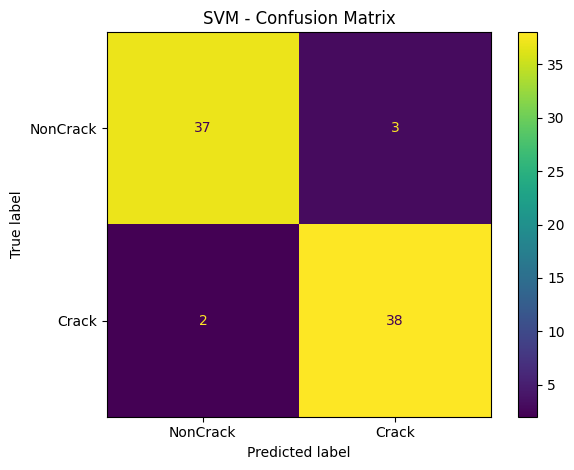

In [32]:
# Calculate confusion matrix
svm_cm = confusion_matrix(
    y_image_test,
    y_image_pred_svm
)

print("SVM Confusion Matrix:")
print(svm_cm)

# Visualize confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=["NonCrack", "Crack"]
).plot()

plt.title("SVM - Confusion Matrix")
plt.tight_layout()
plt.show()

## 29. Final Comparison of Image Classification Models

The four traditional machine-learning classifiers are compared using the evaluation metrics and computational measurements required by the assignment.

The models are:

1. Logistic Regression
2. Random Forest
3. Decision Tree
4. Support Vector Machine (SVM)

All models were evaluated on the same 80-image test set using the same nine extracted image features.

In [33]:
# Final comparison of all image classification models
image_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        dt_accuracy,
        svm_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision,
        dt_precision,
        svm_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        dt_recall,
        svm_recall
    ],
    "F1-Score": [
        logistic_f1,
        rf_f1,
        dt_f1,
        svm_f1
    ],
    "Training Time (s)": [
        logistic_training_time,
        rf_training_time,
        dt_training_time,
        svm_training_time
    ],
    "Prediction Time (s)": [
        logistic_prediction_time,
        rf_prediction_time,
        dt_prediction_time,
        svm_prediction_time
    ]
})

image_model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9375,0.926829,0.950,0.938272,0.039783,0.002196
1,Random Forest,0.9500,0.950000,0.950,0.950000,0.246541,0.010555
2,Decision Tree,0.9375,0.948718,0.925,0.936709,0.004473,0.001706
3,SVM,0.9375,0.926829,0.950,0.938272,0.017697,0.007210


## 30. Part A — Observations

Four traditional machine-learning classifiers were evaluated using the extracted image features.

Random Forest achieved an accuracy of 95.00% and an F1-score of 0.9500 on the test set. Logistic Regression and SVM both achieved an accuracy of 93.75% and an F1-score of 0.9383, while the Decision Tree achieved an accuracy of 93.75% and an F1-score of 0.9367.

The models also showed differences in computational time. Random Forest required more training and prediction time than the other models in this experiment. The Decision Tree had the lowest measured training and prediction times.

Overall, the results show that the handcrafted intensity-based and Canny edge-based image features contain useful information for distinguishing between Crack and NonCrack images. The results are based on the specific train-test split used in this experiment.

# Part B — Text Vectorization and Spam Classification

In this part, the Email Spam Classification Dataset is used to classify emails as spam or non-spam.

The text data will first be inspected and cleaned. It will then be converted into numerical representations using two different vectorization techniques:

1. CountVectorizer
2. TF-IDF Vectorizer

Traditional machine-learning classifiers will then be trained using both representations and their performance and computational requirements will be compared.

## 31. Load the Email Dataset

The email dataset is loaded from `data/emails.csv`.

The dataset will first be inspected to identify its columns, number of records, missing values, and target-label representation before preprocessing the text.

In [34]:
# Load the email dataset
email_dataset_path = "data/emails.csv"

emails_df = pd.read_csv(email_dataset_path)

print("Dataset shape:", emails_df.shape)

print("\nColumn names:")
print(emails_df.columns.tolist())

print("\nFirst five rows:")
display(emails_df.head())

Dataset shape: (5172, 3002)

Column names:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'h

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


## 32. Inspect the Email Dataset Structure

The loaded dataset contains 5,172 emails and 3,002 columns.

The first column appears to contain an email identifier, while the remaining columns appear to contain word-frequency features.

Before performing text preprocessing and vectorization, the final columns and data types are inspected to identify the target variable and determine whether the dataset contains raw email text or an already vectorized representation.

In [35]:
# Inspect the first and last columns of the dataset

print("First 10 columns:")
print(emails_df.columns[:10].tolist())

print("\nLast 10 columns:")
print(emails_df.columns[-10:].tolist())

print("\nLast 5 rows and columns:")
display(emails_df.iloc[:, -10:].head())

print("\nData types of the last 10 columns:")
print(emails_df.iloc[:, -10:].dtypes)

First 10 columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou']

Last 10 columns:
['connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military', 'allowing', 'ff', 'dry', 'Prediction']

Last 5 rows and columns:


,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0



Data types of the last 10 columns:
connevey          int64
jay               int64
valued            int64
lay               int64
infrastructure    int64
military          int64
allowing          int64
ff                int64
dry               int64
Prediction        int64
dtype: object


## 33. Inspect the Email Labels and Existing Representation

The dataset contains an existing `Prediction` column that appears to represent the spam/non-spam target.

The target values and the structure of the existing word-frequency representation are inspected before proceeding with text vectorization.

In [36]:
# Inspect the target column
print("Prediction value counts:")
print(emails_df["Prediction"].value_counts())

print("\nUnique Prediction values:")
print(emails_df["Prediction"].unique())

# Inspect Email No.
print("\nFirst 10 Email No. values:")
print(emails_df["Email No."].head(10).tolist())

# Inspect the range of word-count features
email_word_columns = [
    col for col in emails_df.columns
    if col not in ["Email No.", "Prediction"]
]

print("\nNumber of existing word features:", len(email_word_columns))

print("\nSample word features:")
print(email_word_columns[:20])

print("\nSample values from word features:")
display(emails_df[email_word_columns[:10]].head())

Prediction value counts:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Unique Prediction values:
[0 1]

First 10 Email No. values:
['Email 1', 'Email 2', 'Email 3', 'Email 4', 'Email 5', 'Email 6', 'Email 7', 'Email 8', 'Email 9', 'Email 10']

Number of existing word features: 3000

Sample word features:
['the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with']

Sample values from word features:


,the,to,ect,and,for,of,a,you,hou,in
0,0,0,1,0,0,0,2,0,0,0
1,8,13,24,6,6,2,102,1,27,18
2,0,0,1,0,0,0,8,0,0,4
3,0,5,22,0,5,1,51,2,10,1
4,7,6,17,1,5,2,57,0,9,3


## 34. Dataset Representation Note

The supplied `emails.csv` contains 5,172 email records represented using 3,000 word-frequency features, along with an `Email No.` identifier and a `Prediction` target.

The original email text is not present in this CSV. Therefore, conventional text cleaning operations on raw email strings cannot be directly performed on the supplied file.

To satisfy the vectorization requirement of the assignment, the existing word-frequency representation will be converted into a reconstructed token representation and processed using `CountVectorizer` and `TfidfVectorizer`.

This reconstruction is based on the supplied word-frequency data and should not be interpreted as recovery of the original email text.

## 35. Spam and Non-Spam Class Distribution

The distribution of the target variable is examined before building the classification models.

In this dataset:

- `0` represents one email class.
- `1` represents the other email class.

The class counts are visualized to identify whether the dataset is balanced or imbalanced.

Email class distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64


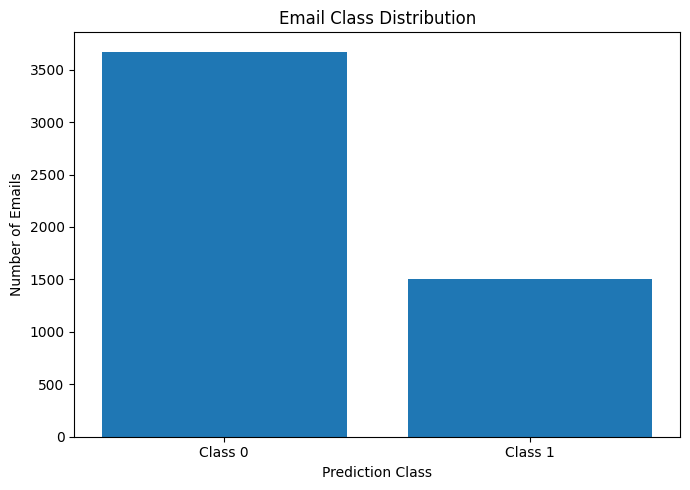

In [37]:
# Display class counts
email_class_counts = emails_df["Prediction"].value_counts().sort_index()

print("Email class distribution:")
print(email_class_counts)

# Visualize class distribution
plt.figure(figsize=(7, 5))

plt.bar(
    ["Class 0", "Class 1"],
    [
        email_class_counts.get(0, 0),
        email_class_counts.get(1, 0)
    ]
)

plt.title("Email Class Distribution")
plt.xlabel("Prediction Class")
plt.ylabel("Number of Emails")

plt.tight_layout()
plt.show()

## 36. Reconstruct Text Representation from Word Frequencies

The supplied dataset contains word-frequency counts rather than raw email text.

For the vectorization experiment, each email is converted into a token sequence by repeating each vocabulary word according to its recorded frequency.

For example:

    word_A = 2
    word_B = 1

is represented as:

    word_A word_A word_B

The resulting reconstructed text is then supplied to `CountVectorizer` and `TfidfVectorizer`.

The original `Email No.` identifier and `Prediction` target are excluded from the representation.

In [38]:
# Columns containing the existing vocabulary
email_word_columns = [
    col for col in emails_df.columns
    if col not in ["Email No.", "Prediction"]
]

# Reconstruct a token-based text representation
def reconstruct_email_text(row):
    tokens = []

    for word in email_word_columns:
        count = int(row[word])

        if count > 0:
            tokens.extend([word] * count)

    return " ".join(tokens)


# Apply reconstruction to all emails
email_text_reconstructed = emails_df.apply(
    reconstruct_email_text,
    axis=1
)

print("Number of reconstructed emails:", len(email_text_reconstructed))

print("\nExample reconstructed email:")
print(email_text_reconstructed.iloc[0][:1000])

Number of reconstructed emails: 5172

Example reconstructed email:
ect a a is i i s s s as re re e e e e t t t t j m m b p c c c r r r r f h u u tu st ic far chris hr rm tr pictures pi ma picture ct ct christmas ur tm


## 37. Train-Test Split for Email Classification

The reconstructed email representations and their corresponding labels are divided into training and testing sets.

An 80:20 stratified split is used so that the proportion of the two classes is maintained in both subsets.

Importantly, the vectorizers will be fitted only on the training text and then used to transform the test text. This prevents information from the test set from influencing the learned vocabulary or feature weights.

In [39]:
# Prepare email target
y_email = emails_df["Prediction"]

# Split reconstructed text and target
email_text_train, email_text_test, y_email_train, y_email_test = train_test_split(
    email_text_reconstructed,
    y_email,
    test_size=0.20,
    random_state=42,
    stratify=y_email
)

print("Training emails:", len(email_text_train))
print("Testing emails:", len(email_text_test))

print("\nTraining class distribution:")
print(y_email_train.value_counts())

print("\nTesting class distribution:")
print(y_email_test.value_counts())

Training emails: 4137
Testing emails: 1035

Training class distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing class distribution:
Prediction
0    735
1    300
Name: count, dtype: int64


## 38. CountVectorizer Representation

CountVectorizer converts text into a matrix of token occurrence counts.

Each row represents an email and each column represents a vocabulary term. The value in each cell indicates the number of times that term occurs in the corresponding email.

The vectorizer is fitted only on the training data and then used to transform both the training and testing data.

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

# Create CountVectorizer
count_vectorizer = CountVectorizer()

# Fit only on training data
count_train = count_vectorizer.fit_transform(email_text_train)

# Transform test data using the learned vocabulary
count_test = count_vectorizer.transform(email_text_test)

print("CountVectorizer representation")
print("-" * 40)
print("Training matrix shape:", count_train.shape)
print("Testing matrix shape :", count_test.shape)

print("\nNumber of generated features:", len(count_vectorizer.get_feature_names_out()))

CountVectorizer representation
----------------------------------------
Training matrix shape: (4137, 2974)
Testing matrix shape : (1035, 2974)

Number of generated features: 2974


## 39. Logistic Regression with CountVectorizer

A Logistic Regression classifier is trained using the CountVectorizer representation.

Logistic Regression is suitable for high-dimensional numerical text representations and can operate directly on the sparse feature matrix generated by CountVectorizer.

Training and prediction times are recorded for comparison with the TF-IDF representation.

In [41]:
# Create Logistic Regression model for CountVectorizer
count_lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Measure training time
count_lr_start_time = time.perf_counter()

count_lr_model.fit(count_train, y_email_train)

count_lr_training_time = time.perf_counter() - count_lr_start_time

# Measure prediction time
count_lr_prediction_start_time = time.perf_counter()

y_email_pred_count = count_lr_model.predict(count_test)

count_lr_prediction_time = time.perf_counter() - count_lr_prediction_start_time

print(f"Training time: {count_lr_training_time:.6f} seconds")
print(f"Prediction time: {count_lr_prediction_time:.6f} seconds")

C:\Users\pujit\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Training time: 1.301358 seconds
Prediction time: 0.005321 seconds


## 40. Evaluate CountVectorizer + Logistic Regression

The Logistic Regression model trained on the CountVectorizer representation is evaluated on the unseen test set.

The evaluation uses accuracy, precision, recall, and F1-score. These metrics are considered together because the email classes are not perfectly balanced.

In [42]:
# Calculate evaluation metrics
count_accuracy = accuracy_score(
    y_email_test,
    y_email_pred_count
)

count_precision = precision_score(
    y_email_test,
    y_email_pred_count
)

count_recall = recall_score(
    y_email_test,
    y_email_pred_count
)

count_f1 = f1_score(
    y_email_test,
    y_email_pred_count
)

print("CountVectorizer + Logistic Regression Results")
print("-" * 50)
print(f"Accuracy : {count_accuracy:.4f}")
print(f"Precision: {count_precision:.4f}")
print(f"Recall   : {count_recall:.4f}")
print(f"F1-score : {count_f1:.4f}")

CountVectorizer + Logistic Regression Results
--------------------------------------------------
Accuracy : 0.9807
Precision: 0.9545
Recall   : 0.9800
F1-score : 0.9671


## 41. Confusion Matrix — CountVectorizer

The confusion matrix is generated for the Logistic Regression classifier trained using CountVectorizer.

This shows the number of correctly and incorrectly classified emails for each class.

CountVectorizer Confusion Matrix:
[[721  14]
 [  6 294]]


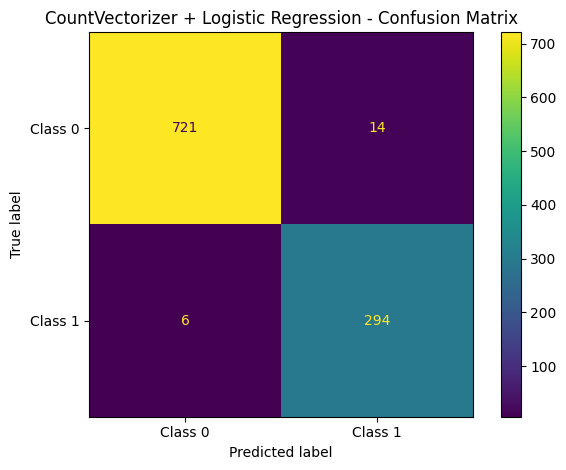

In [43]:
# Calculate confusion matrix
count_cm = confusion_matrix(
    y_email_test,
    y_email_pred_count
)

print("CountVectorizer Confusion Matrix:")
print(count_cm)

# Visualize confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=count_cm,
    display_labels=["Class 0", "Class 1"]
).plot()

plt.title("CountVectorizer + Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

## 42. TF-IDF Vectorization

TF-IDF (Term Frequency-Inverse Document Frequency) converts the reconstructed email text into numerical vectors while assigning weights to terms based on their frequency within a document and their distribution across the document collection.

Unlike CountVectorizer, which represents terms using occurrence counts, TF-IDF reduces the relative importance of terms that occur frequently across many documents.

The vectorizer is fitted only on the training data and then used to transform both the training and testing data.

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit only on training data
tfidf_train = tfidf_vectorizer.fit_transform(email_text_train)

# Transform test data using the learned vocabulary
tfidf_test = tfidf_vectorizer.transform(email_text_test)

print("TF-IDF representation")
print("-" * 40)
print("Training matrix shape:", tfidf_train.shape)
print("Testing matrix shape :", tfidf_test.shape)

print("\nNumber of generated features:",
      len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF representation
----------------------------------------
Training matrix shape: (4137, 2974)
Testing matrix shape : (1035, 2974)

Number of generated features: 2974


## 43. Logistic Regression with TF-IDF

The same Logistic Regression classifier used with CountVectorizer is trained using the TF-IDF representation.

Using the same classifier, train-test split, and evaluation metrics allows the effect of the feature representation to be compared more directly.

Training time and prediction time are recorded.

In [45]:
# Create Logistic Regression model for TF-IDF
tfidf_lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Measure training time
tfidf_lr_start_time = time.perf_counter()

tfidf_lr_model.fit(tfidf_train, y_email_train)

tfidf_lr_training_time = time.perf_counter() - tfidf_lr_start_time

# Measure prediction time
tfidf_lr_prediction_start_time = time.perf_counter()

y_email_pred_tfidf = tfidf_lr_model.predict(tfidf_test)

tfidf_lr_prediction_time = time.perf_counter() - tfidf_lr_prediction_start_time

print(f"Training time: {tfidf_lr_training_time:.6f} seconds")
print(f"Prediction time: {tfidf_lr_prediction_time:.6f} seconds")

C:\Users\pujit\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Training time: 0.244151 seconds
Prediction time: 0.013797 seconds


## 44. Evaluate TF-IDF + Logistic Regression

The Logistic Regression classifier trained using the TF-IDF representation is evaluated on the same test set used for the CountVectorizer experiment.

Accuracy, precision, recall, and F1-score are calculated for direct comparison between the two representations.

In [46]:
# Calculate TF-IDF evaluation metrics
tfidf_accuracy = accuracy_score(
    y_email_test,
    y_email_pred_tfidf
)

tfidf_precision = precision_score(
    y_email_test,
    y_email_pred_tfidf
)

tfidf_recall = recall_score(
    y_email_test,
    y_email_pred_tfidf
)

tfidf_f1 = f1_score(
    y_email_test,
    y_email_pred_tfidf
)

print("TF-IDF + Logistic Regression Results")
print("-" * 50)
print(f"Accuracy : {tfidf_accuracy:.4f}")
print(f"Precision: {tfidf_precision:.4f}")
print(f"Recall   : {tfidf_recall:.4f}")
print(f"F1-score : {tfidf_f1:.4f}")

TF-IDF + Logistic Regression Results
--------------------------------------------------
Accuracy : 0.9768
Precision: 0.9510
Recall   : 0.9700
F1-score : 0.9604


## 45. Confusion Matrix — TF-IDF

The confusion matrix is generated for the Logistic Regression classifier trained using the TF-IDF representation.

This allows the class-wise prediction errors to be compared with the CountVectorizer model.

TF-IDF Confusion Matrix:
[[720  15]
 [  9 291]]


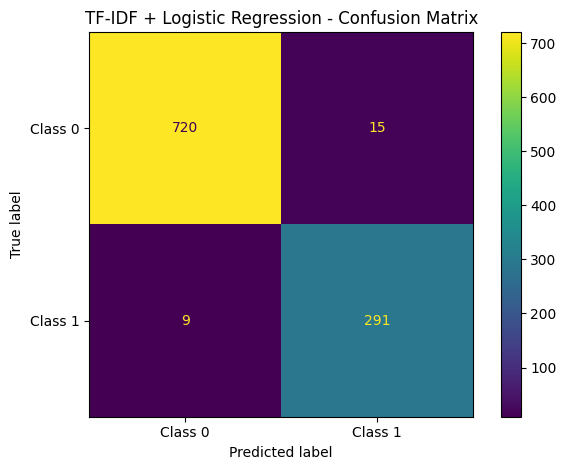

In [47]:
# Calculate confusion matrix
tfidf_cm = confusion_matrix(
    y_email_test,
    y_email_pred_tfidf
)

print("TF-IDF Confusion Matrix:")
print(tfidf_cm)

# Visualize confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=tfidf_cm,
    display_labels=["Class 0", "Class 1"]
).plot()

plt.title("TF-IDF + Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

## 46. CountVectorizer vs TF-IDF Comparison

CountVectorizer and TF-IDF are compared using the same:

- Training and testing split
- Logistic Regression classifier
- Test dataset

The comparison considers:

- Number of generated features
- Accuracy
- Precision
- Recall
- F1-score
- Training time
- Prediction time

This allows the effect of the text representation on classification performance and computational cost to be examined.

In [48]:
# Final comparison of CountVectorizer and TF-IDF
text_vectorizer_comparison = pd.DataFrame({
    "Representation": [
        "CountVectorizer",
        "TF-IDF"
    ],
    "Number of Features": [
        count_train.shape[1],
        tfidf_train.shape[1]
    ],
    "Accuracy": [
        count_accuracy,
        tfidf_accuracy
    ],
    "Precision": [
        count_precision,
        tfidf_precision
    ],
    "Recall": [
        count_recall,
        tfidf_recall
    ],
    "F1-Score": [
        count_f1,
        tfidf_f1
    ],
    "Training Time (s)": [
        count_lr_training_time,
        tfidf_lr_training_time
    ],
    "Prediction Time (s)": [
        count_lr_prediction_time,
        tfidf_lr_prediction_time
    ]
})

text_vectorizer_comparison

,Representation,Number of Features,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,CountVectorizer,2974,0.980676,0.954545,0.98,0.967105,1.301358,0.005321
1,TF-IDF,2974,0.976812,0.950980,0.97,0.960396,0.244151,0.013797


## 47. Part B — Observations

CountVectorizer and TF-IDF were evaluated using the same training/testing split and Logistic Regression classifier.

Both representations generated 2,974 features. CountVectorizer achieved an accuracy of 98.07% and an F1-score of 0.9671, while TF-IDF achieved an accuracy of 97.68% and an F1-score of 0.9604 on the test set.

CountVectorizer therefore produced slightly higher predictive metrics in this experiment. TF-IDF required less measured training time (0.2442 seconds compared with 1.3014 seconds for CountVectorizer), while its measured prediction time was higher.

The confusion matrices showed that CountVectorizer produced 20 misclassifications, whereas TF-IDF produced 24 misclassifications on the 1,035-email test set.

These results are specific to the dataset, reconstructed text representation, classifier, and train-test split used in this experiment.